<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/W1_DIFRAKSI_CELAH_TUNGGAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-1-e60273ef6986>:23: RuntimeWarning: invalid value encountered in divide
  intensitas_teori = (np.sin(beta) / beta) ** 2


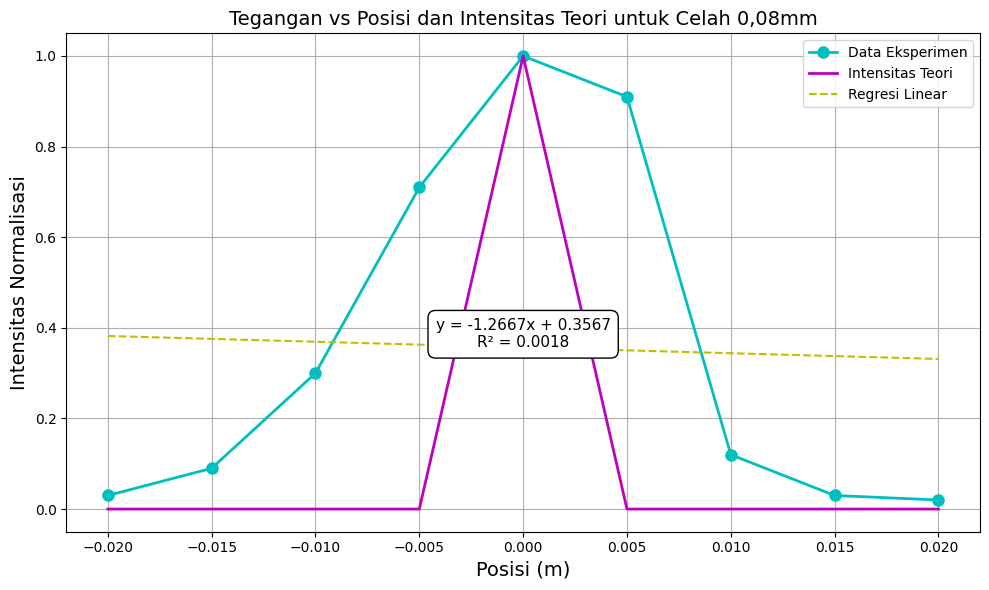

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data posisi (dalam mm) dan tegangan (dalam mV)
pos = np.array([-20, -15, -10, -5, 0, 5, 10, 15, 20])
tegangan_mv = np.array([0.3, 0.9, 3, 7.1, 10, 9.1, 1.2, 0.3, 0.2])

# Normalisasi tegangan sebagai intensitas eksperimen
intensitas_exp = tegangan_mv / np.max(tegangan_mv)

# Parameter model teori
a = 1  # jumlah kisi per satuan panjang
lambda_cahaya = 520e-9  # panjang gelombang 520 nm
jarak_kelayar = 1  # jarak ke layar dalam meter

# Ubah posisi ke meter
x_m = pos * 1e-3

# Hitung beta
beta = (np.pi * a * x_m) / (lambda_cahaya * jarak_kelayar)

# Hitung intensitas teori (gunakan rumus sin(beta)/beta)
intensitas_teori = (np.sin(beta) / beta) ** 2
intensitas_teori[np.isnan(intensitas_teori)] = 1.0
intensitas_teori = intensitas_teori / np.max(intensitas_teori)

# Regresi linear
koef = np.polyfit(x_m, intensitas_exp, 1)
hasil_regresi = np.polyval(koef, x_m)
R2 = 1 - np.sum((intensitas_exp - hasil_regresi) ** 2) / np.sum((intensitas_exp - np.mean(intensitas_exp)) ** 2)

# Plot hasil
plt.figure(figsize=(10, 6))
plt.plot(x_m, intensitas_exp, 'co-', linewidth=2, markersize=8, label='Data Eksperimen')     # cyan
plt.plot(x_m, intensitas_teori, 'm-', linewidth=2, label='Intensitas Teori')                 # magenta
plt.plot(x_m, hasil_regresi, 'y--', linewidth=1.5, label='Regresi Linear')                   # kuning

plt.grid(True)
plt.xlabel('Posisi (m)', fontsize=14)
plt.ylabel('Intensitas Normalisasi', fontsize=14)
plt.title('Tegangan vs Posisi dan Intensitas Teori untuk Celah 0,08mm', fontsize=14)
plt.legend(fontsize=10, loc='upper right')

# Tampilkan persamaan regresi dan R²
plt.text(np.mean(x_m), np.mean(intensitas_exp),
         f'y = {koef[0]:.4f}x + {koef[1]:.4f}\nR² = {R2:.4f}',
         fontsize=11,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'),
         ha='center')

plt.tight_layout()
plt.show()


<ipython-input-3-6762c82e5db6>:23: RuntimeWarning: invalid value encountered in divide
  intensitas_teori = (np.sin(beta) / beta) ** 2


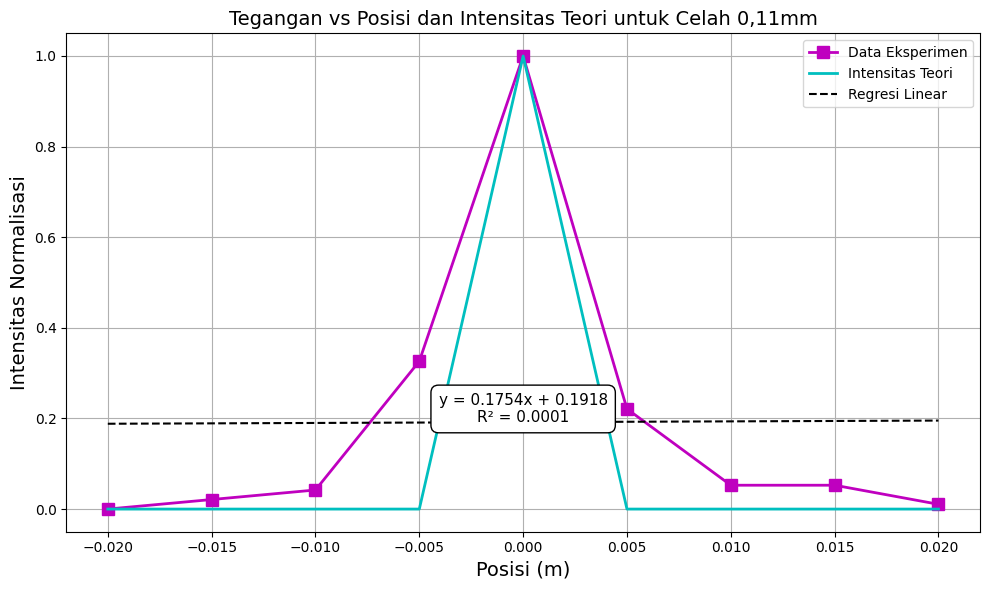

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data posisi (mm) dan tegangan (mV)
pos = np.array([-20, -15, -10, -5, 0, 5, 10, 15, 20])
volt = np.array([0, 0.2, 0.4, 3.1, 9.5, 2.1, 0.5, 0.5, 0.1])

# Normalisasi nilai tegangan
intensitas_exp = volt / np.max(volt)

# Parameter model teori
a = 1  # jumlah kisi per satuan panjang (diasumsikan)
panjang_gelombang = 520e-9  # 520 nm dalam meter
jarak_layar = 1  # jarak kisi ke layar (m)

# Konversi satuan posisi ke meter
x_meter = pos * 1e-3

# Menghitung beta
beta = (np.pi * a * x_meter) / (panjang_gelombang * jarak_layar)

# Hitung intensitas teoretis (gunakan np.sinc untuk menghindari pembagian nol)
intensitas_teori = (np.sin(beta) / beta) ** 2
intensitas_teori[np.isnan(intensitas_teori)] = 1.0
intensitas_teori = intensitas_teori / np.max(intensitas_teori)

# Regresi linear pada data eksperimen
koef = np.polyfit(x_meter, intensitas_exp, 1)
fit_line = np.polyval(koef, x_meter)
R2_score = 1 - np.sum((intensitas_exp - fit_line) ** 2) / np.sum((intensitas_exp - np.mean(intensitas_exp)) ** 2)

# Visualisasi grafik
plt.figure(figsize=(10, 6))
plt.plot(x_meter, intensitas_exp, 'ms-', linewidth=2, markersize=8, label='Data Eksperimen')  # magenta
plt.plot(x_meter, intensitas_teori, 'c-', linewidth=2, label='Intensitas Teori')              # cyan
plt.plot(x_meter, fit_line, 'k--', linewidth=1.5, label='Regresi Linear')                     # black

plt.grid(True)
plt.xlabel('Posisi (m)', fontsize=14)
plt.ylabel('Intensitas Normalisasi', fontsize=14)
plt.title('Tegangan vs Posisi dan Intensitas Teori untuk Celah 0,11mm', fontsize=14)
plt.legend(fontsize=10, loc='upper right')

# Tampilkan persamaan dan R² pada grafik
plt.text(np.mean(x_meter), np.mean(intensitas_exp),
         f'y = {koef[0]:.4f}x + {koef[1]:.4f}\nR² = {R2_score:.4f}',
         fontsize=11,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'),
         ha='center')

plt.tight_layout()
plt.show()


Hasil Perhitungan Difraksi Celah Tunggal:
   Orde_m  y_mm   lambda_nm  Delta_lambda_nm  Error_Nisbi_%
0       1   6.0  324.324324        48.724159      26.017263
1       2  15.5  418.918919        54.081182       4.438964
2       3  25.5  459.459459        58.135556       4.808878
3       4  36.0  486.486486        61.185918      10.974106
4       5  46.5  502.702703        63.070815      14.673243

Rata-rata panjang gelombang: 438.4 nm
Persamaan Regresi: y = 42.43 m + 311.08
Koefisien Determinasi (R²): 0.8877


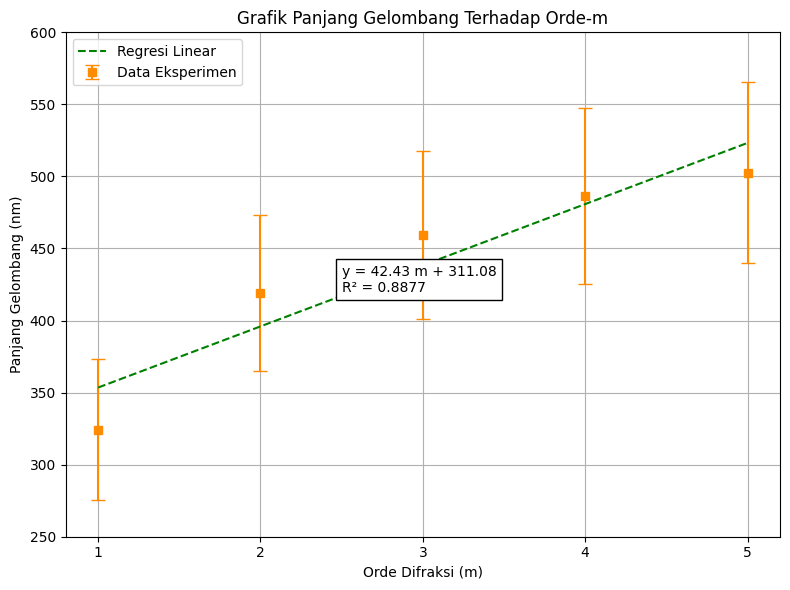

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parameter eksperimen
lebar_celah = 0.08e-3       # dalam meter
jarak_layar = 1.48          # dalam meter
uncertainty_a = 0.01e-3     # ketidakpastian lebar celah (m)
uncertainty_y = 0.5e-3      # ketidakpastian posisi (m)
uncertainty_D = 0.001       # ketidakpastian jarak ke layar (m)

# Data eksperimen
orde = np.array([1, 2, 3, 4, 5])
posisi_mm = np.array([6, 15.5, 25.5, 36, 46.5])
posisi_m = posisi_mm * 1e-3  # konversi ke meter

# Hitung panjang gelombang
lambda_meter = (lebar_celah * posisi_m) / (orde * jarak_layar)
lambda_nanometer = lambda_meter * 1e9

# Hitung ketidakpastian panjang gelombang
rel_error = np.sqrt((uncertainty_a / lebar_celah)**2 +
                    (uncertainty_y / posisi_m)**2 +
                    (uncertainty_D / jarak_layar)**2)
delta_lambda = rel_error * lambda_nanometer

# Hitung error nisbi terhadap rata-rata
rata_lambda = np.mean(lambda_nanometer)
error_nisbi = np.abs((lambda_nanometer - rata_lambda) / rata_lambda) * 100

# Regresi linier
koef = np.polyfit(orde, lambda_nanometer, 1)
fit_line = np.polyval(koef, orde)

# Koefisien determinasi
SS_total = np.sum((lambda_nanometer - rata_lambda)**2)
SS_res = np.sum((lambda_nanometer - fit_line)**2)
R2 = 1 - (SS_res / SS_total)

# Buat tabel hasil
hasil_df = pd.DataFrame({
    'Orde_m': orde,
    'y_mm': posisi_mm,
    'lambda_nm': lambda_nanometer,
    'Delta_lambda_nm': delta_lambda,
    'Error_Nisbi_%': error_nisbi
})

print("Hasil Perhitungan Difraksi Celah Tunggal:")
print(hasil_df)
print(f"\nRata-rata panjang gelombang: {rata_lambda:.1f} nm")
print(f"Persamaan Regresi: y = {koef[0]:.2f} m + {koef[1]:.2f}")
print(f"Koefisien Determinasi (R²): {R2:.4f}")

# Visualisasi grafik
plt.figure(figsize=(8,6))
plt.errorbar(orde, lambda_nanometer, yerr=delta_lambda, fmt='s', color='darkorange',
             ecolor='darkorange', capsize=5, label='Data Eksperimen')  # ganti warna ke oranye tua
plt.plot(orde, fit_line, 'g--', label='Regresi Linear')  # ganti warna ke hijau

# Tambahkan teks regresi dan R²
plt.text(2.5, 420, f'y = {koef[0]:.2f} m + {koef[1]:.2f}\nR² = {R2:.4f}',
         fontsize=10, bbox=dict(facecolor='white'))

plt.xlabel('Orde Difraksi (m)')
plt.ylabel('Panjang Gelombang (nm)')
plt.title('Grafik Panjang Gelombang Terhadap Orde-m')
plt.legend(loc='upper left')
plt.grid(True)
plt.xticks(orde)
plt.ylim(250, 600)

plt.tight_layout()
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.9 MB/s eta 0:00:00


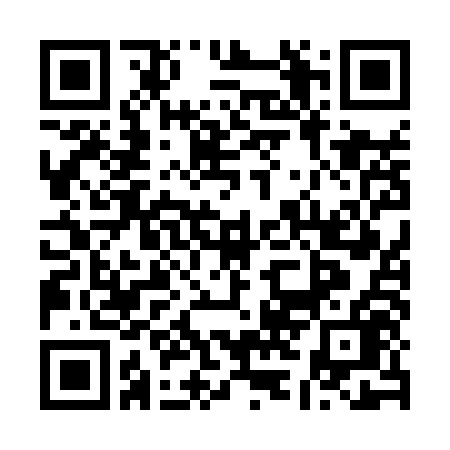

In [ ]:
from re import S
# prompt: coba buat qr code dengan  menyematkan link

!pip install qrcode

import qrcode

# Link yang ingin disematkan dalam QR Code
link = "https://colab.research.google.com/drive/190B4M-W3f8Khz3RbymY8PB2TZUtVGlLr#scrollTo=Sk6VptK5Wr40"  # Ganti dengan link yang diinginkan

# Membuat objek QR Code
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_L,
    box_size=10,
    border=4,
)

# Menambahkan data (link) ke QR Code
qr.add_data(link)
qr.make(fit=True)

# Membuat gambar QR Code
img = qr.make_image(fill_color="black", back_color="white")

# Menyimpan gambar QR Code
img.save("qrcode_link.png")

display(img)
